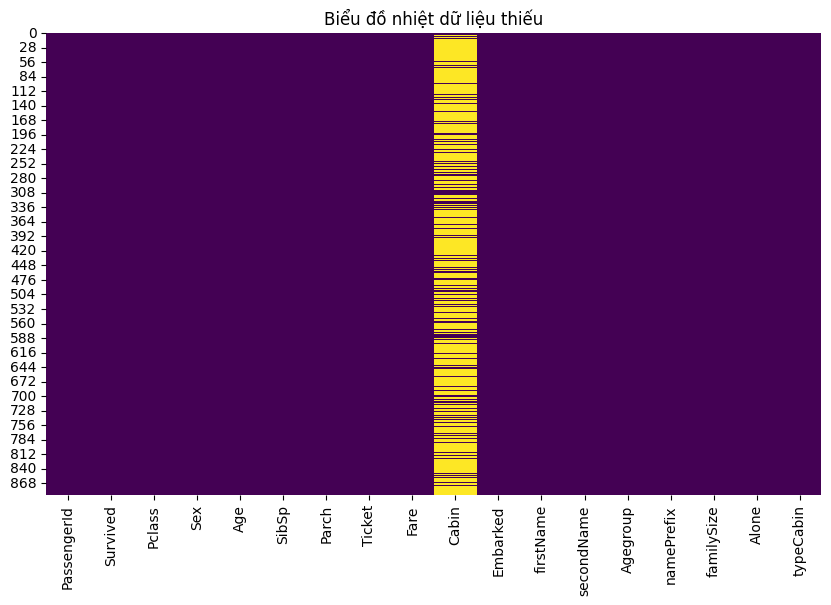

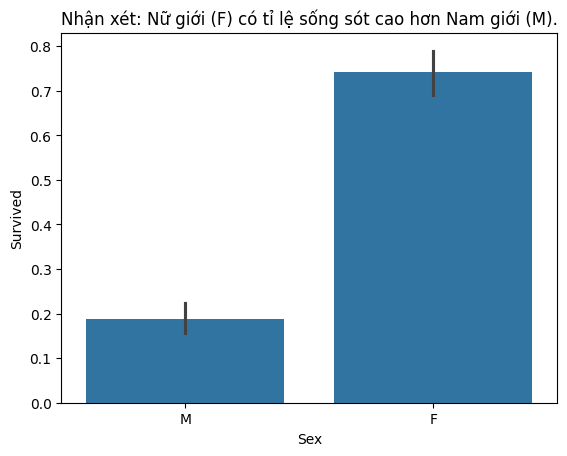

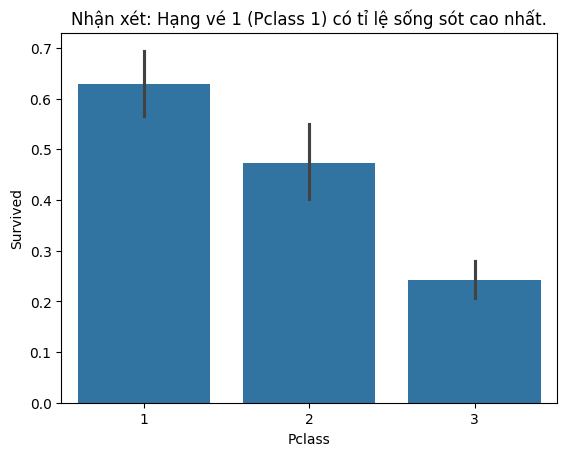

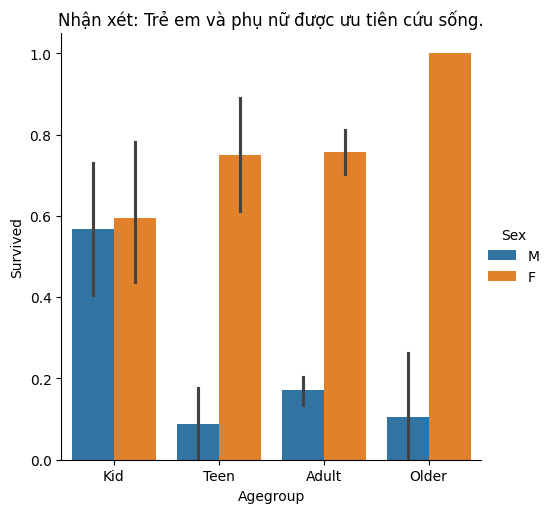

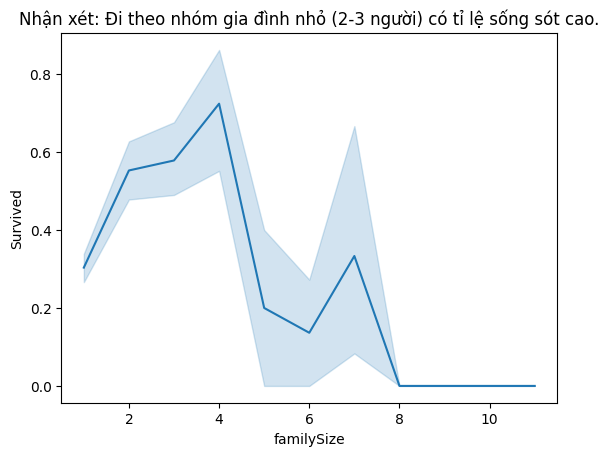

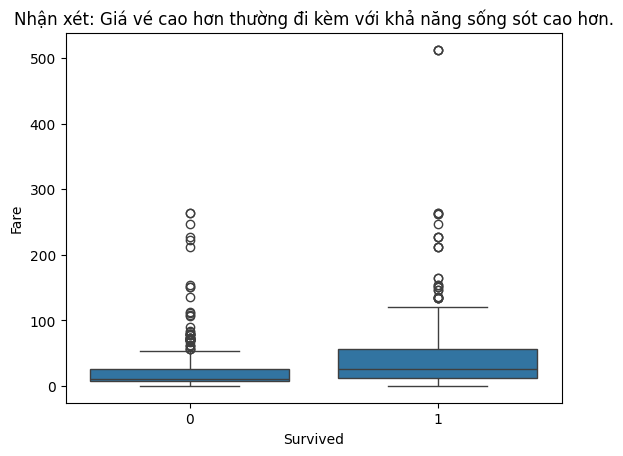

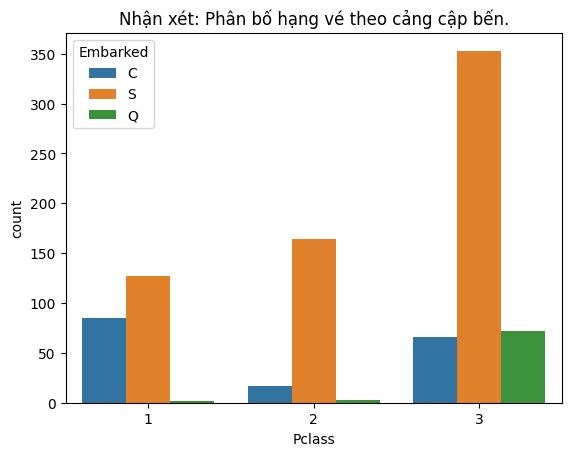

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- CÁC HÀM XỬ LÝ (Dùng cho pipe) ---
def load_data(path):
    # Đọc file dữ liệu
    return pd.read_csv(path)

def clean_data(df):
    # Tách Name thành firstName và secondName
    if 'Name' in df.columns:
        df[['firstName', 'secondName']] = df['Name'].str.split(',', expand=True)
        df = df.drop(columns=['Name'])
    # Rút gọn Sex
    df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})
    return df

def fill_age(df):
    # Thay thế Age bị thiếu bằng giá trị trung bình theo hạng vé (Pclass)
    df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))
    return df

def feature_engineering(df):
    # Agegroup
    bins = [0, 12, 18, 60, 100]
    labels = ['Kid', 'Teen', 'Adult', 'Older']
    df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
    # NamePrefix
    df['namePrefix'] = df['secondName'].str.extract(r' ([A-Za-z]+)\.')
    # FamilySize & Alone
    df['familySize'] = 1 + df['SibSp'] + df['Parch']
    df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)
    # TypeCabin
    df['typeCabin'] = df['Cabin'].fillna('Unknown').str[0]
    return df

# --- THỰC THI CHƯƠNG TRÌNH ---
df = load_data('titanic_disaster.csv')

# Áp dụng các bước xử lý qua pipe 
df = (df.pipe(clean_data)
        .pipe(fill_age)
        .pipe(feature_engineering))

# Trực quan hóa dữ liệu thiếu
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Biểu đồ nhiệt dữ liệu thiếu")
plt.show()

# --- PHẦN 2: EDA (Trực quan hóa & Nhận xét) ---
def plot_eda(df):
    # 12. Sex
    sns.barplot(x='Sex', y='Survived', data=df)
    plt.title("Nhận xét: Nữ giới (F) có tỉ lệ sống sót cao hơn Nam giới (M).")
    plt.show()
    
    # 13. Pclass
    sns.barplot(x='Pclass', y='Survived', data=df)
    plt.title("Nhận xét: Hạng vé 1 (Pclass 1) có tỉ lệ sống sót cao nhất.")
    plt.show()
    
    # 14. Sex + Agegroup
    sns.catplot(x='Agegroup', y='Survived', hue='Sex', kind='bar', data=df)
    plt.title("Nhận xét: Trẻ em và phụ nữ được ưu tiên cứu sống.")
    plt.show()

    # 15. FamilySize
    sns.lineplot(x='familySize', y='Survived', data=df)
    plt.title("Nhận xét: Đi theo nhóm gia đình nhỏ (2-3 người) có tỉ lệ sống sót cao.")
    plt.show()

    # 16. Fare
    sns.boxplot(x='Survived', y='Fare', data=df)
    plt.title("Nhận xét: Giá vé cao hơn thường đi kèm với khả năng sống sót cao hơn.")
    plt.show()

    # 17. Pclass + Embarked
    if 'Embarked' in df.columns:
        sns.countplot(x='Pclass', hue='Embarked', data=df)
        plt.title("Nhận xét: Phân bố hạng vé theo cảng cập bến.")
        plt.show()

plot_eda(df)
